# Weather Source Comparison with EHR Similarity Transfer

Goal: test whether building physical parameters from EHR can improve ES-style portfolio modeling by transferring coefficients between similar buildings.

This notebook reuses existing project data only:
- building heat and KKP weather via `utils.building_data_loader`
- Copernicus weather from `data/combined_weather_2022_2025.csv`
- EHR features from `data/ehr-building-data/ehr_building_summary.csv`

Experiment design:
1. Build daily common-target datasets per building (same `Phi_kWh` for KKP and COP)
2. Fit baseline models on train period (ES v1, ARX-ES)
3. Build EHR similarity matrix across buildings
4. Create donor coefficients from nearest EHR-similar buildings
5. Evaluate blended local+donor coefficients on chronological test holdout
6. Compare baseline vs transfer for KKP and COP


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from utils.building_data_loader import get_building_dataframe, load_campus_metadata

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

warnings.filterwarnings('ignore', category=RuntimeWarning)


## Configuration

In [2]:
WEATHER_FILE = PROJECT_ROOT / 'data' / 'combined_weather_2022_2025.csv'
EHR_FILE = PROJECT_ROOT / 'data' / 'ehr-building-data' / 'ehr_building_summary.csv'

TRAIN_END = pd.Timestamp('2023-12-31')
MIN_TRAIN_DAYS = 120
MIN_TEST_DAYS = 60
TOP_K_DONORS = 3
SHRINKAGE_TAU = 180.0  # larger => stronger pull toward donor coefficients

ALL_MODELS = {
    'ES_v1': {
        'kkp': ['kkp_dT', 'kkp_wind'],
        'cop': ['cop_dT', 'cop_wind'],
    },
    'ARX_ES': {
        'kkp': ['kkp_dT', 'kkp_wind', 'Phi_lag1'],
        'cop': ['cop_dT', 'cop_wind', 'Phi_lag1'],
    },
}

print(f'Weather file: {WEATHER_FILE}')
print(f'EHR file:     {EHR_FILE}')


Weather file: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/combined_weather_2022_2025.csv
EHR file:     /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/ehr-building-data/ehr_building_summary.csv


## Helpers

In [3]:
EHR_CODE_MAP = {
    'U02': 'U02 (+U02B)',
    'U02B': 'U02 (+U02B)',
    'U03': 'U03 (+U03B)',
    'U03B': 'U03 (+U03B)',
    'U06': 'U06 (+U06A)',
    'U06A': 'U06 (+U06A)',
}


def map_to_ehr_code(building_code: str) -> str:
    return EHR_CODE_MAP.get(building_code, building_code)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def extract_theta(model: LinearRegression) -> np.ndarray:
    return np.concatenate(([float(model.intercept_)], np.asarray(model.coef_, dtype=float)))


def predict_from_theta(theta: np.ndarray, X: pd.DataFrame) -> np.ndarray:
    intercept = theta[0]
    coefs = theta[1:]
    return intercept + X.to_numpy(dtype=float) @ coefs


def fit_theta(df: pd.DataFrame, features: list, target: str = 'Phi_kWh'):
    d = df.dropna(subset=features + [target]).copy()
    if len(d) < MIN_TRAIN_DAYS:
        return None, None
    X = d[features]
    y = d[target]
    lm = LinearRegression().fit(X, y)
    return extract_theta(lm), len(d)


def eval_theta(df: pd.DataFrame, theta: np.ndarray, features: list, target: str = 'Phi_kWh'):
    d = df.dropna(subset=features + [target]).copy()
    if len(d) < MIN_TEST_DAYS:
        return {'n_test': len(d), 'r2': np.nan, 'rmse': np.nan}
    pred = predict_from_theta(theta, d[features])
    y = d[target].to_numpy(dtype=float)
    return {
        'n_test': len(d),
        'r2': float(r2_score(y, pred)),
        'rmse': rmse(y, pred),
    }


def aggregate_daily_common(building_code: str, weather_df: pd.DataFrame, overview_df: pd.DataFrame, building_codes_df: pd.DataFrame, t_base: float = 15.0):
    # Load heat + KKP weather, and heat-only for COP merge.
    df_kkp = get_building_dataframe(
        building_code,
        overview_df=overview_df,
        building_codes_df=building_codes_df,
        include_weather=True,
        verbose=False,
    )
    df_heat = get_building_dataframe(
        building_code,
        overview_df=overview_df,
        building_codes_df=building_codes_df,
        include_weather=False,
        verbose=False,
    )

    heat_cols = [c for c in df_heat.columns if 'measurement_delta_mwh' in c]
    if not heat_cols:
        raise ValueError('No heat meter columns')

    cop_cols = [c for c in weather_df.columns if c.startswith('COP_')]
    df_cop = df_heat.merge(weather_df[cop_cols], left_on='datetime', right_index=True, how='left')

    # Heat target aggregated once (source-independent y).
    df_heat['Phi_kWh'] = df_heat[heat_cols].sum(axis=1) * 1e3
    h = df_heat[['datetime', 'Phi_kWh']].dropna().copy()
    h['date'] = h['datetime'].dt.date
    dh = h.groupby('date', as_index=False).agg(Phi_kWh=('Phi_kWh', 'sum'))
    dh = dh[dh['Phi_kWh'] > 0].copy()

    # Daily weather per source.
    ktw = df_kkp[['datetime', 'air_temp_c', 'wind_speed_ms']].dropna().copy()
    ktw['date'] = ktw['datetime'].dt.date
    dktw = ktw.groupby('date', as_index=False).agg(
        kkp_T=('air_temp_c', 'mean'),
        kkp_wind=('wind_speed_ms', 'mean'),
    )

    ctw = df_cop[['datetime', 'COP_temp_c', 'COP_wind_speed_ms']].dropna().copy()
    ctw['date'] = ctw['datetime'].dt.date
    dctw = ctw.groupby('date', as_index=False).agg(
        cop_T=('COP_temp_c', 'mean'),
        cop_wind=('COP_wind_speed_ms', 'mean'),
    )

    # Common-date join.
    common = sorted(set(dh['date']) & set(dktw['date']) & set(dctw['date']))
    d = dh[dh['date'].isin(common)].copy().reset_index(drop=True)
    d = d.merge(dktw, on='date', how='inner').merge(dctw, on='date', how='inner')
    d['datetime'] = pd.to_datetime(d['date'])
    d = d.sort_values('datetime').reset_index(drop=True)

    d['kkp_dT'] = t_base - d['kkp_T']
    d['cop_dT'] = t_base - d['cop_T']
    d['Phi_lag1'] = d['Phi_kWh'].shift(1)

    return d


def split_train_test(daily_df: pd.DataFrame):
    train = daily_df[daily_df['datetime'] <= TRAIN_END].copy()
    test = daily_df[daily_df['datetime'] > TRAIN_END].copy()
    return train, test


## Load Inputs

In [4]:
overview_df, building_codes_df = load_campus_metadata()
weather_df = pd.read_csv(WEATHER_FILE, parse_dates=['datetime'], index_col='datetime')
ehr_df = pd.read_csv(EHR_FILE)

all_buildings = sorted([b for b in overview_df['Hoone'].dropna().unique().tolist() if b != 'NRG'])

print(f'Buildings in portfolio run: {len(all_buildings)}')
print(all_buildings)
print(f'EHR rows: {len(ehr_df)}')


Buildings in portfolio run: 17
['GEO', 'ICO', 'LIB', 'SOC', 'STU', 'U01', 'U01U02', 'U02', 'U02B', 'U03', 'U03B', 'U04', 'U04B', 'U05', 'U05B', 'U06', 'U06A']
EHR rows: 16


## Build Daily Datasets per Building

In [5]:
daily_by_building = {}
errors = {}

for code in all_buildings:
    try:
        d = aggregate_daily_common(code, weather_df, overview_df, building_codes_df)
        train, test = split_train_test(d)
        if len(train) < MIN_TRAIN_DAYS or len(test) < MIN_TEST_DAYS:
            errors[code] = f'insufficient split (train={len(train)}, test={len(test)})'
            continue
        daily_by_building[code] = d
    except Exception as e:
        errors[code] = str(e)

print(f'Usable buildings: {len(daily_by_building)}')
print(f'Skipped buildings: {len(errors)}')
if errors:
    print(pd.Series(errors).sort_index())


Usable buildings: 15
Skipped buildings: 2
STU        insufficient split (train=642, test=4)
U01U02    insufficient split (train=698, test=10)
dtype: object


## Fit Baseline Coefficients on Train and Evaluate on Test

In [6]:
coef_records = []
metric_records = []

for code, d in daily_by_building.items():
    train, test = split_train_test(d)

    for model_name, source_features in ALL_MODELS.items():
        for source, feats in source_features.items():
            theta, n_train = fit_theta(train, feats)
            if theta is None:
                continue

            ev = eval_theta(test, theta, feats)
            coef_records.append({
                'building': code,
                'model': model_name,
                'source': source,
                'features': feats,
                'theta': theta,
                'n_train': n_train,
            })
            metric_records.append({
                'building': code,
                'model': model_name,
                'source': source,
                'variant': 'baseline_local',
                'n_train': n_train,
                **ev,
            })

coef_df = pd.DataFrame(coef_records)
metrics_df = pd.DataFrame(metric_records)

print(f'Coefficient rows: {len(coef_df)}')
print(f'Metric rows:      {len(metrics_df)}')
metrics_df.head()


Coefficient rows: 60
Metric rows:      60


,building,model,source,variant,n_train,n_test,r2,rmse
0,GEO,ES_v1,kkp,baseline_local,552,346,0.438210,171.546401
1,GEO,ES_v1,cop,baseline_local,552,346,0.417901,174.619641
2,GEO,ARX_ES,kkp,baseline_local,551,346,0.718694,121.390420
3,GEO,ARX_ES,cop,baseline_local,551,346,0.716428,121.878390
4,ICO,ES_v1,kkp,baseline_local,569,357,0.869856,272.179579


## Build EHR Similarity Matrix

In [7]:
ehr_numeric_cols = [
    'first_use_year',
    'gross_volume_m3',
    'footprint_area_m2',
    'heated_area_m2',
    'max_floors',
    'height_m',
    'volume_per_heated_area',
    'compactness_ratio',
    'orientation_azimuth_deg',
    'orientation_edge_share',
]

available_cols = [c for c in ehr_numeric_cols if c in ehr_df.columns]

code_to_ehr = {code: map_to_ehr_code(code) for code in daily_by_building.keys()}
feature_rows = []
for code, ehr_code in code_to_ehr.items():
    r = ehr_df[ehr_df['campus_code'] == ehr_code]
    if r.empty:
        continue
    row = r.iloc[0]
    item = {'building': code, 'ehr_code': ehr_code}
    for c in available_cols:
        item[c] = row.get(c)
    feature_rows.append(item)

feature_df = pd.DataFrame(feature_rows)

for c in available_cols:
    feature_df[c] = pd.to_numeric(feature_df[c], errors='coerce')

# Median imputation + z-score scaling.
X = feature_df[available_cols].copy()
X = X.fillna(X.median(numeric_only=True))
X = (X - X.mean()) / X.std(ddof=0).replace(0, 1)

feature_df_scaled = feature_df[['building', 'ehr_code']].copy()
for c in available_cols:
    feature_df_scaled[c] = X[c]

buildings_ehr = feature_df_scaled['building'].tolist()
X_mat = feature_df_scaled[available_cols].to_numpy(dtype=float)

dist_mat = np.sqrt(((X_mat[:, None, :] - X_mat[None, :, :]) ** 2).sum(axis=2))
dist_df = pd.DataFrame(dist_mat, index=buildings_ehr, columns=buildings_ehr)

print(f'Buildings with EHR mapping: {len(buildings_ehr)}/{len(daily_by_building)}')
feature_df[['building', 'ehr_code'] + available_cols[:5]].head(10)


Buildings with EHR mapping: 15/15


,building,ehr_code,first_use_year,gross_volume_m3,footprint_area_m2,heated_area_m2,max_floors
0,GEO,GEO,2006,3875.0,719.0,898.2,2
1,ICO,ICO,2008,18237.2,1131.5,0.0,5
2,LIB,LIB,2009,43567.0,2424.5,10647.0,7
3,SOC,SOC,2009,45882.4,3324.5,10360.0,5
4,U01,U01,1968,21780.0,1030.0,4088.7,2
5,U02,U02 (+U02B),1967,24136.0,1931.0,24136.0,4
6,U02B,U02 (+U02B),1967,24136.0,1931.0,24136.0,4
7,U03,U03 (+U03B),1966,30456.0,2826.0,5908.0,4
8,U03B,U03 (+U03B),1966,30456.0,2826.0,5908.0,4
9,U04,U04,1965,24521.0,1736.0,5777.1,4


## Similarity-Based Donor and Blended Coefficients

In [8]:
def get_donors(target_building: str, candidate_buildings: list, k: int = TOP_K_DONORS):
    if target_building not in dist_df.index:
        return []
    d = dist_df.loc[target_building, candidate_buildings].sort_values()
    d = d[d.index != target_building]
    return list(d.head(k).items())  # [(building, distance), ...]


def weighted_average_theta(theta_list, dist_list):
    # Closer donors get higher weight.
    w = np.exp(-np.asarray(dist_list, dtype=float))
    if w.sum() == 0:
        w = np.ones_like(w)
    w = w / w.sum()
    stacked = np.vstack(theta_list)
    return np.average(stacked, axis=0, weights=w)


def blend_thetas(local_theta, donor_theta, n_train: int, tau: float = SHRINKAGE_TAU):
    alpha = float(n_train) / float(n_train + tau)
    return alpha * local_theta + (1.0 - alpha) * donor_theta, alpha


transfer_records = []
donor_records = []

for _, row in coef_df.iterrows():
    b = row['building']
    model_name = row['model']
    source = row['source']
    feats = row['features']
    theta_local = row['theta']
    n_train = int(row['n_train'])

    # Donor candidates: same model and source, different building.
    candidates_df = coef_df[
        (coef_df['model'] == model_name)
        & (coef_df['source'] == source)
        & (coef_df['building'] != b)
    ].copy()
    candidates = candidates_df['building'].tolist()
    donors = get_donors(b, candidates, k=TOP_K_DONORS)

    if not donors:
        continue

    donor_buildings = [name for name, _ in donors]
    donor_dist = [float(dist) for _, dist in donors]

    donor_thetas = []
    for dname in donor_buildings:
        dtheta = candidates_df[candidates_df['building'] == dname]['theta'].iloc[0]
        donor_thetas.append(dtheta)

    theta_donor = weighted_average_theta(donor_thetas, donor_dist)
    theta_blend, alpha = blend_thetas(theta_local, theta_donor, n_train=n_train, tau=SHRINKAGE_TAU)

    d_all = daily_by_building[b]
    _, test = split_train_test(d_all)

    baseline_eval = eval_theta(test, theta_local, feats)
    donor_eval = eval_theta(test, theta_donor, feats)
    blend_eval = eval_theta(test, theta_blend, feats)

    transfer_records.extend([
        {
            'building': b,
            'model': model_name,
            'source': source,
            'variant': 'baseline_local',
            'alpha_local': 1.0,
            **baseline_eval,
        },
        {
            'building': b,
            'model': model_name,
            'source': source,
            'variant': 'donor_only',
            'alpha_local': 0.0,
            **donor_eval,
        },
        {
            'building': b,
            'model': model_name,
            'source': source,
            'variant': 'blended_local_donor',
            'alpha_local': alpha,
            **blend_eval,
        },
    ])

    donor_records.append({
        'building': b,
        'model': model_name,
        'source': source,
        'donors': donor_buildings,
        'donor_distances': donor_dist,
        'alpha_local': alpha,
    })

transfer_df = pd.DataFrame(transfer_records)
donor_df = pd.DataFrame(donor_records)

print(f'Transfer result rows: {len(transfer_df)}')
print(f'Donor metadata rows:  {len(donor_df)}')
transfer_df.head()


Transfer result rows: 180
Donor metadata rows:  60


,building,model,source,variant,alpha_local,n_test,r2,rmse
0,GEO,ES_v1,kkp,baseline_local,1.000000,346,0.438210,171.546401
1,GEO,ES_v1,kkp,donor_only,0.000000,346,-89.169090,2173.319578
2,GEO,ES_v1,kkp,blended_local_donor,0.754098,346,-3.865460,504.843409
3,GEO,ES_v1,cop,baseline_local,1.000000,346,0.417901,174.619641
4,GEO,ES_v1,cop,donor_only,0.000000,346,-86.115966,2136.208443


## Summary: Baseline vs Blended

In [9]:
if transfer_df.empty:
    raise RuntimeError('No transfer results were generated. Check EHR mapping and minimum-day thresholds.')

summary = (
    transfer_df[transfer_df['variant'].isin(['baseline_local', 'blended_local_donor'])]
    .pivot_table(index=['building', 'model', 'source'], columns='variant', values=['r2', 'rmse', 'n_test'], aggfunc='first')
)
summary.columns = ['_'.join(c).strip() for c in summary.columns]
summary = summary.reset_index()
summary['delta_r2_blend_minus_base'] = summary['r2_blended_local_donor'] - summary['r2_baseline_local']
summary['delta_rmse_blend_minus_base'] = summary['rmse_blended_local_donor'] - summary['rmse_baseline_local']

print('Mean effect by source and model:')
mean_effect = summary.groupby(['source', 'model'])[['delta_r2_blend_minus_base', 'delta_rmse_blend_minus_base']].mean().round(4)
display(mean_effect)

print('Building-level deltas (sorted by delta R2):')
display(summary.sort_values('delta_r2_blend_minus_base', ascending=False).head(20))


Mean effect by source and model:


delta_r2_blend_minus_base  delta_rmse_blend_minus_base
source model                                                         
cop    ARX_ES                    -0.1304                      26.7606
       ES_v1                     -1.1881                      88.4222
kkp    ARX_ES                    -0.1389                      27.9103
       ES_v1                     -1.2359                      90.7441

Building-level deltas (sorted by delta R2):


,building,model,source,n_test_baseline_local,n_test_blended_local_donor,r2_baseline_local,r2_blended_local_donor,rmse_baseline_local,rmse_blended_local_donor,delta_r2_blend_minus_base,delta_rmse_blend_minus_base
55,U06,ES_v1,kkp,308,308,-0.099656,0.279731,2456.219910,1987.860918,0.379388,-468.358992
54,U06,ES_v1,cop,308,308,-0.067463,0.294205,2419.998699,1967.787430,0.361667,-452.211269
39,U04,ES_v1,kkp,297,297,0.311224,0.503781,3048.869240,2587.833724,0.192557,-461.035516
38,U04,ES_v1,cop,297,297,0.327996,0.507935,3011.518784,2576.980346,0.179938,-434.538437
31,U03,ES_v1,kkp,301,301,0.344423,0.477138,1416.296486,1264.841010,0.132715,-151.455475
30,U03,ES_v1,cop,301,301,0.363724,0.488730,1395.292221,1250.741365,0.125006,-144.550856
41,U04B,ARX_ES,kkp,281,281,0.401588,0.469876,1146.870041,1079.450632,0.068288,-67.419409
40,U04B,ARX_ES,cop,281,281,0.414121,0.479655,1134.797263,1069.448273,0.065535,-65.348990
53,U06,ARX_ES,kkp,308,308,0.671915,0.726530,1341.626866,1224.880606,0.054615,-116.746260
52,U06,ARX_ES,cop,308,308,0.679508,0.729982,1326.011631,1217.124401,0.050474,-108.887230


## COP vs KKP Gap: Does Transfer Change the Weather-Source Difference?

In [10]:
# Build gap table for baseline and blended variants.
gap_rows = []
for variant in ['baseline_local', 'blended_local_donor']:
    t = transfer_df[transfer_df['variant'] == variant]
    piv = t.pivot_table(index=['building', 'model'], columns='source', values='r2', aggfunc='first').reset_index()
    if 'kkp' in piv.columns and 'cop' in piv.columns:
        piv['variant'] = variant
        piv['cop_minus_kkp_r2'] = piv['cop'] - piv['kkp']
        gap_rows.append(piv)

gap_df = pd.concat(gap_rows, ignore_index=True)

print('Mean COP-KKP R2 gap (negative means KKP better):')
display(gap_df.groupby(['variant', 'model'])['cop_minus_kkp_r2'].mean().round(4).unstack('model'))

print('Per-building COP-KKP gap:')
display(gap_df.sort_values(['model', 'building']))


Mean COP-KKP R2 gap (negative means KKP better):


model,ARX_ES,ES_v1
variant,,
baseline_local,0.0018,0.0185
blended_local_donor,0.0102,0.0663


Per-building COP-KKP gap:


source,building,model,cop,kkp,variant,cop_minus_kkp_r2
0,GEO,ARX_ES,0.716428,0.718694,baseline_local,-0.002266
30,GEO,ARX_ES,0.272968,0.246660,blended_local_donor,0.026308
2,ICO,ARX_ES,0.960687,0.960766,baseline_local,-0.000078
32,ICO,ARX_ES,0.941636,0.938512,blended_local_donor,0.003124
4,LIB,ARX_ES,0.814365,0.817985,baseline_local,-0.003620
34,LIB,ARX_ES,0.807564,0.809886,blended_local_donor,-0.002322
6,SOC,ARX_ES,0.225949,0.229131,baseline_local,-0.003182
36,SOC,ARX_ES,0.203222,0.206697,blended_local_donor,-0.003475
8,U01,ARX_ES,0.710572,0.706460,baseline_local,0.004112
38,U01,ARX_ES,0.708442,0.705278,blended_local_donor,0.003164


## Donor Inspection

In [11]:
# Show donor sets used for each building/model/source.
if donor_df.empty:
    print('No donor assignments available.')
else:
    display(donor_df.sort_values(['building', 'model', 'source']).head(40))

# Example: nearest neighbors by EHR similarity for selected buildings.
for b in ['U06', 'U05', 'LIB', 'SOC', 'ICT']:
    if b not in dist_df.index:
        continue
    nn = dist_df.loc[b].drop(index=b).sort_values().head(5)
    print(f'\nNearest EHR neighbors for {b}:')
    print(nn)


,building,model,source,donors,donor_distances,alpha_local
3,GEO,ARX_ES,cop,"[U05B, U04B, U04]","[5.475886191523036, 5.656890229756551, 6.40559...",0.753762
2,GEO,ARX_ES,kkp,"[U05B, U04B, U04]","[5.475886191523036, 5.656890229756551, 6.40559...",0.753762
1,GEO,ES_v1,cop,"[U05B, U04B, U04]","[5.475886191523036, 5.656890229756551, 6.40559...",0.754098
0,GEO,ES_v1,kkp,"[U05B, U04B, U04]","[5.475886191523036, 5.656890229756551, 6.40559...",0.754098
7,ICO,ARX_ES,cop,"[SOC, U05B, U04]","[3.469596422102227, 4.032031961608558, 4.55960...",0.759358
6,ICO,ARX_ES,kkp,"[SOC, U05B, U04]","[3.469596422102227, 4.032031961608558, 4.55960...",0.759358
5,ICO,ES_v1,cop,"[SOC, U05B, U04]","[3.469596422102227, 4.032031961608558, 4.55960...",0.759680
4,ICO,ES_v1,kkp,"[SOC, U05B, U04]","[3.469596422102227, 4.032031961608558, 4.55960...",0.759680
11,LIB,ARX_ES,cop,"[SOC, U06, U06A]","[3.14178216698073, 3.3505751544091384, 3.35057...",0.696459
10,LIB,ARX_ES,kkp,"[SOC, U06, U06A]","[3.14178216698073, 3.3505751544091384, 3.35057...",0.696459



Nearest EHR neighbors for U06:
U06A    0.000000
SOC     2.830472
U03     3.015249
U03B    3.015249
U05     3.089559
Name: U06, dtype: float64

Nearest EHR neighbors for U05:
U04     1.316916
U03     1.545556
U03B    1.545556
U05B    2.839879
U06     3.089559
Name: U05, dtype: float64

Nearest EHR neighbors for LIB:
SOC     3.141782
U06     3.350575
U06A    3.350575
U05B    3.756646
U05     3.835759
Name: LIB, dtype: float64

Nearest EHR neighbors for SOC:
U06     2.830472
U06A    2.830472
LIB     3.141782
ICO     3.469596
U05     3.808752
Name: SOC, dtype: float64


## Visual Diagnostics

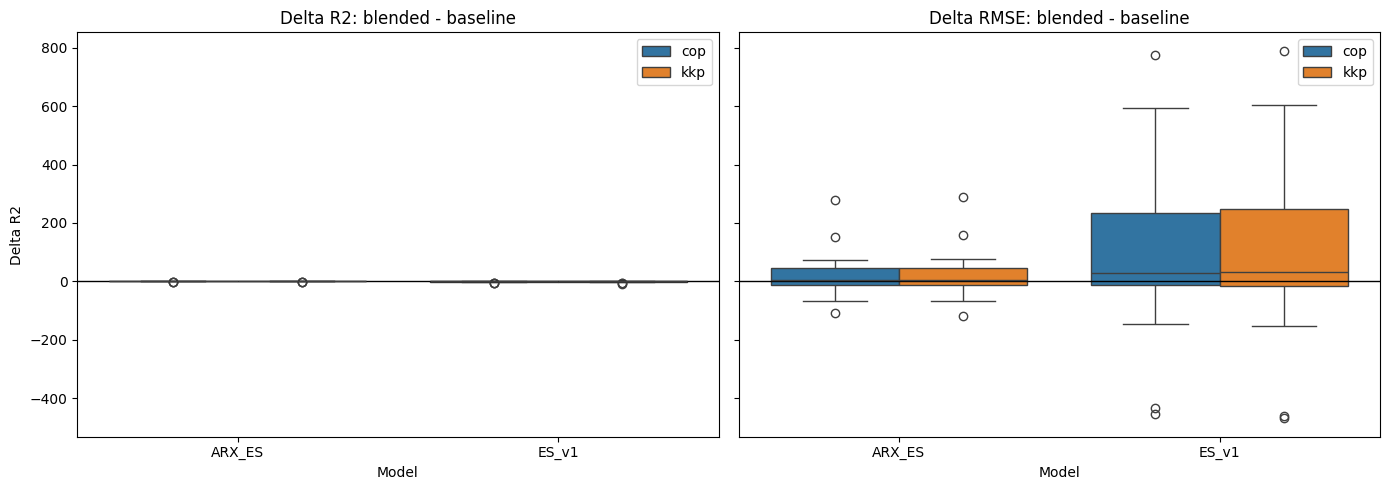

In [12]:
plot_df = summary.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.boxplot(data=plot_df, x='model', y='delta_r2_blend_minus_base', hue='source', ax=axes[0])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Delta R2: blended - baseline')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Delta R2')

sns.boxplot(data=plot_df, x='model', y='delta_rmse_blend_minus_base', hue='source', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Delta RMSE: blended - baseline')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Delta RMSE (kWh/day)')

for ax in axes:
    ax.legend(loc='best')

plt.tight_layout()
plt.show()


## Interpretation Checklist

Use this notebook to answer these thesis-relevant questions:

1. Does EHR-based transfer improve chronological holdout performance vs local-only baseline?
2. Is the effect stronger for buildings with shorter/noisier training history?
3. Does transfer help both weather sources similarly, or mainly COP?
4. Does transfer reduce variance across buildings (more robust portfolio behavior)?
5. Which EHR-similar donors are repeatedly selected, and are they physically plausible matches?

If this experiment shows consistent gains, the same transfer mechanism can be reused in your ML stage (for feature priors, parameter initialization, or grouped cross-building training).
